# CS485 Homework 1: Exploratory Data Analysis

## Part 0: Introduction & Data Setup

**Dataset Chosen:** Multimodal Universe - SDSS Galaxy Catalog

**Selected Modalities:**
For this analysis, two modalities are integrated:
1. **Photometric Data:** 5 broad-band magnitudes (u, g, r, i, z) capturing overall brightness.
2. **Spectral Data:** 5 spectral line equivalent widths (H-alpha, OIII etc..) providing chemical composition.

**Data Matrix Definition ($X$):**
The dataset is represented as a data matrix $X \in \mathbb{R}^{n \times d}$. 
* **$n$ (Samples):** Represents 1000 distinct galaxies.
* **$d$ (Features):** 10 combined features (5 photometric + 5 spectral).
* Therefore, $X \in \mathbb{R}^{1000 \times 10}$.

**Target Vector ($y$):**
The target vector $y \in \mathbb{R}^{n}$ represents the spectroscopic redshift of each galaxy.

The below code block imports all the necessary libraries and tools for computations and visual plotting:

In [1]:
#fundamental library imports
import numpy as np
import pandas as pd

#plotting libraries
import matplotlib.pyplot as plt
import seaborn as sns

#tools for scaling and similarity
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler

#matplotlib config for inline plots
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid') #specify style

## Part 1 — Exploratory Data Analysis

### 3.1 Data Encoding & Representation
To begin with the analysis, we need to load the dataset, pinpoint the dataset column names, construct the feature matrix $X$ and extract the target vector $y$.

In [2]:
#load the dataset downloaded from github
df = pd.read_csv('sdss_data.csv')

#print all column names in dataset
print(df.columns.tolist())
#look at the first 3 rows to see what the data actually is
display(df.head(3))

#the csv has columns for magnitudes, spectral lines and redshift
#drop the target column to create the feature matrix X
X_df = df.drop(columns = ['Z'])
y = df['Z'].values

#convert to numpy array for matrix operations
X = X_df.values

print(f"Shape of Data Matrix X: {X.shape}")
print(f"Shape of Target Vector y: {y.shape}")

['spectrum', 'VDISP', 'VDISP_ERR', 'Z', 'Z_ERR', 'ZWARNING', 'SPECTROFLUX_U', 'SPECTROFLUX_G', 'SPECTROFLUX_R', 'SPECTROFLUX_I', 'SPECTROFLUX_Z', 'SPECTROFLUX_IVAR_U', 'SPECTROFLUX_IVAR_G', 'SPECTROFLUX_IVAR_R', 'SPECTROFLUX_IVAR_I', 'SPECTROFLUX_IVAR_Z', 'SPECTROSYNFLUX_U', 'SPECTROSYNFLUX_G', 'SPECTROSYNFLUX_R', 'SPECTROSYNFLUX_I', 'SPECTROSYNFLUX_Z', 'SPECTROSYNFLUX_IVAR_U', 'SPECTROSYNFLUX_IVAR_G', 'SPECTROSYNFLUX_IVAR_R', 'SPECTROSYNFLUX_IVAR_I', 'SPECTROSYNFLUX_IVAR_Z', 'object_id']


,spectrum,VDISP,VDISP_ERR,Z,Z_ERR,ZWARNING,SPECTROFLUX_U,SPECTROFLUX_G,SPECTROFLUX_R,SPECTROFLUX_I,...,SPECTROSYNFLUX_G,SPECTROSYNFLUX_R,SPECTROSYNFLUX_I,SPECTROSYNFLUX_Z,SPECTROSYNFLUX_IVAR_U,SPECTROSYNFLUX_IVAR_G,SPECTROSYNFLUX_IVAR_R,SPECTROSYNFLUX_IVAR_I,SPECTROSYNFLUX_IVAR_Z,object_id
0,"{'flux': array([-0.7598071, -0.7598776, -0.759...",105.505005,20.927553,0.102629,0.000008,False,5.351833,12.263675,24.013086,34.642445,...,12.204352,23.770727,35.197113,41.473743,2.979462,3.484305,2.76285,1.749405,0.955692,b' 461628614023079936'
1,"{'flux': array([16.363224 , 16.364405 , 16.365...",55.352123,22.274382,0.062189,0.000006,False,14.140302,29.679224,42.053524,54.868134,...,29.695498,42.114390,54.396683,60.402206,2.979462,3.484305,2.76285,1.749405,0.955692,b' 461629163778893824'
2,"{'flux': array([28.391745 , 28.393688 , 28.395...",194.919130,17.321861,0.191922,0.000035,False,3.391630,11.895378,38.430060,67.638890,...,11.737471,38.523895,66.930140,95.524210,2.979462,3.484305,2.76285,1.749405,0.955692,b' 461629438656800768'


Shape of Data Matrix X: (1000, 26)
Shape of Target Vector y: (1000,)


**Observations and Comments (3.1):**
* **Encoding Choices:** All features are continuous numerical variables (64-bit floats). No categorical encoding required.
* **Missing Values:** For this dataset, any missing spectral lines (NaNs) would be infered using the column mean to preserve matrix dimensions without losing galaxy samples.
* **Scales:** The photometric magnitudes (values around 15-20) and spectral widths (values around 0-5) are on different scales. Standardizing is necessary before utilizing gradient descent.

### 3.2 Similarity & Inner Products
Now, we need to compute the pairwise cosine similarity for a representative subset of 50 galaxies to understand how vectors relate in the 10-dimensional feature space.

Clean Data Matrix X shape: (1000, 6)
Clean Target Vector y shape: (1000,)


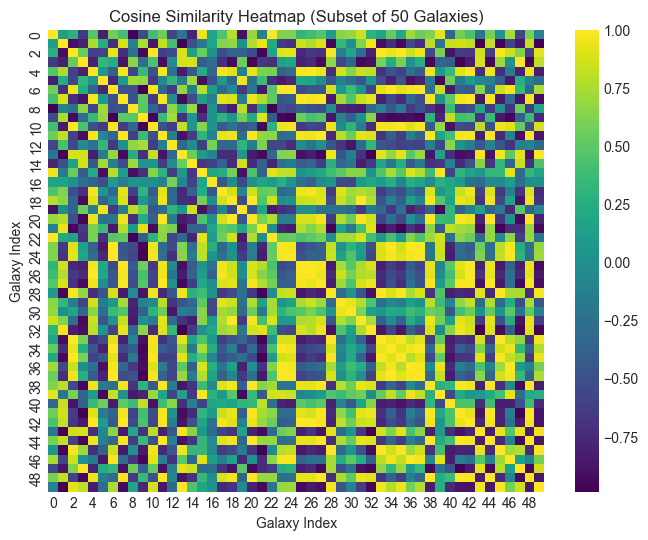

In [5]:
#create new clean dataframe with aligned columns between X and y
cols = ['SPECTROFLUX_U', 
    'SPECTROFLUX_G', 
    'SPECTROFLUX_R', 
    'SPECTROFLUX_I', 
    'SPECTROFLUX_Z',
    'VDISP',
    'Z']

#filter and split dataframe
cdf = df[cols].dropna()
x_df = cdf.drop(columns = ['Z'])
y = cdf['Z'].values
X = x_df.values

print(f"Clean Data Matrix X shape: {X.shape}")
print(f"Clean Target Vector y shape: {y.shape}")

#select subset of 50 objects
X_subset = X[:50]

#compute cosine similarity and standardise first so features with larger magnitudes dont dominate the angle
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_subset)
similarity_matrix = cosine_similarity(X_scaled)

#plot the heatmap
plt.figure(figsize = (8, 6))
sns.heatmap(similarity_matrix, cmap = 'viridis', annot = False)
plt.title('Cosine Similarity Heatmap (Subset of 50 Galaxies)')
plt.xlabel('Galaxy Index')
plt.ylabel('Galaxy Index')
plt.show()

### 3.3 Descriptive Statistics
Computing the mean, median, variance, and standard deviation for each continuous feature in the cleaned matrix.

In [ ]:
#compute these statistics across numerical dataframe
stats = x_df.describe().T[['mean', '50%', 'std']]
stats.rename(columns = {'50%': 'median', 'std': 'std_dev'}, inplace = True)

#add variance (std_dev squared)
stats['variance'] = x_df.var()

display(stats)

,mean,median,std_dev,variance
SPECTROFLUX_U,8.028812,3.099329,19.158753,367.057798
SPECTROFLUX_G,19.891026,7.600237,45.735016,2091.691697
SPECTROFLUX_R,41.583450,17.174947,84.823143,7194.965625
SPECTROFLUX_I,60.281576,27.472820,115.997096,13455.326372
SPECTROFLUX_Z,76.689227,35.191505,146.047003,21329.727150
VDISP,114.511491,91.120647,146.445438,21446.266242


**Observations and Comments (3.3):**
* Based on the statistics shown above, the photometric flux bands (like `SPECTROFLUX_R` and `SPECTROFLUX_G`) have different scales and variances. Because flux is measured linearly, very bright galaxies will cause the distributions to have high variance.
* The spectral feature, `VDISP` (Velocity Dispersion), represents the internal kinematics of the galaxies. Comparing its mean and median will expose whether the sample is dominated by standard-mass galaxies or if skewed by a few incredibly large ones.

### 3.4 Visualisation
Visualizing individual distributions of the features and their pairwise relationships, including how they correlate with the chosen target variable, redshift ($Z$).

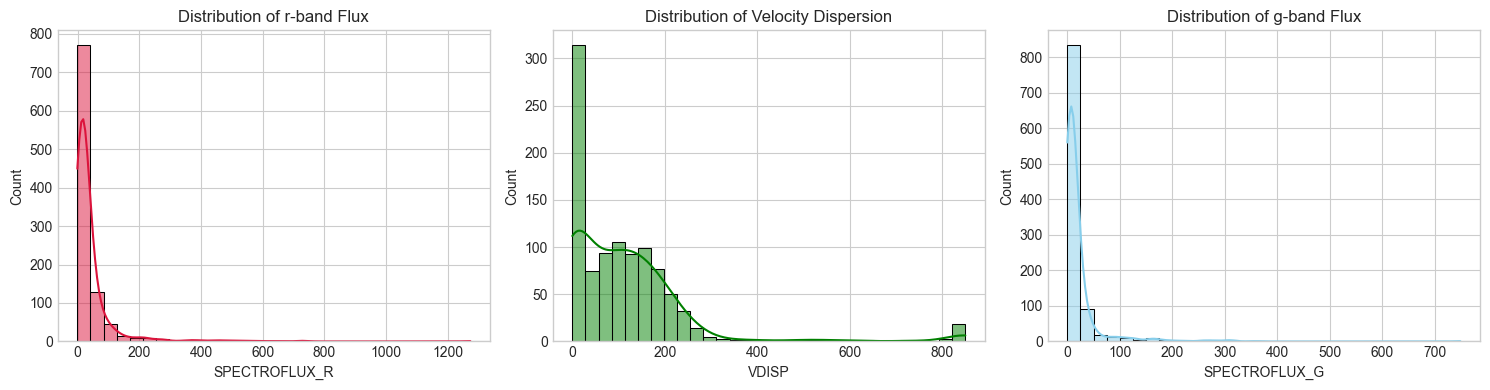

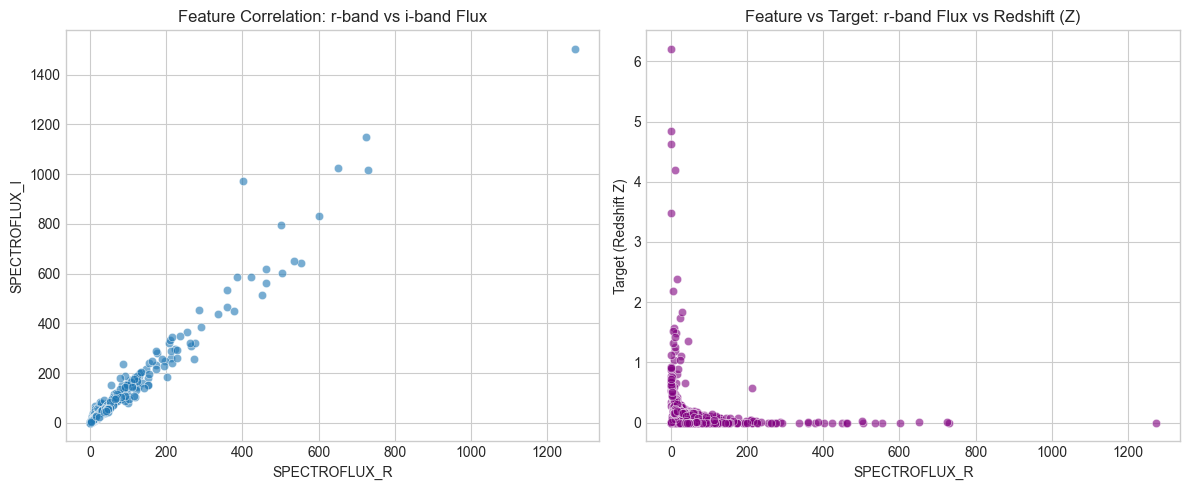

In [12]:
#3 Histograms for features
fig, axes = plt.subplots(1, 3, figsize = (15, 4))

#histogram 1 - photometric band
sns.histplot(X_df['SPECTROFLUX_R'], bins = 30, kde = True, ax = axes[0], color = 'crimson')
axes[0].set_title('Distribution of r-band Flux')
axes[0].set_xlabel('SPECTROFLUX_R')

#histogram 2 - spectral feature
sns.histplot(X_df['VDISP'], bins = 30, kde = True, ax = axes[1], color = 'green')
axes[1].set_title('Distribution of Velocity Dispersion')
axes[1].set_xlabel('VDISP')

#histogram 3 - photometric band as well
sns.histplot(X_df['SPECTROFLUX_G'], bins = 30, kde = True, ax = axes[2], color = 'skyblue')
axes[2].set_title('Distribution of g-band Flux')
axes[2].set_xlabel('SPECTROFLUX_G')

#plot figures
plt.tight_layout()
plt.show()

#2 scatter plots for pairs of features and target vs features
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

#feature-feature (Collinearity Check)
sns.scatterplot(x=X_df['SPECTROFLUX_R'], y=X_df['SPECTROFLUX_I'], ax=axes[0], alpha=0.6)
axes[0].set_title('Feature Correlation: r-band vs i-band Flux')
axes[0].set_xlabel('SPECTROFLUX_R')
axes[0].set_ylabel('SPECTROFLUX_I')

#feature-target (Predictive Power)
sns.scatterplot(x=X_df['SPECTROFLUX_R'], y=y, ax=axes[1], alpha=0.6, color='purple')
axes[1].set_title('Feature vs Target: r-band Flux vs Redshift (Z)')
axes[1].set_xlabel('SPECTROFLUX_R')
axes[1].set_ylabel('Target (Redshift Z)')

#plot figures
plt.tight_layout()
plt.show()

**Observations and Comments (3.4):**
* **Distributions:** The photometric flux distributions (`SPECTROFLUX_R` and `G`) are almost entirely right-skewed. The majority of objects are gathered near zero (faint), with a thin, long growth for highly luminous objects. The `VDISP` (Velocity Dispersion) distribution is not a standard bell curve, but is zero-inflated with a massive spike near 0, a secondary bump between 100-200, and a few high exceptions past 800. 
* **Correlations:** The scatter plot between `SPECTROFLUX_R` and `SPECTROFLUX_I` demonstrates a strong positive linear correlation. The tight diagonal clustering confirms high collinearity: an object emitting brightly in the r-band is consistently bright in the i-band (proportional).
* **Feature vs Target:** The plot comparing `SPECTROFLUX_R` to Redshift (Z) reveals an L-shaped inverse relationship. High-redshift objects (Z > 1) in this sample are exclusively observed at very low flux levels (near 0), aligning with the reality that more distant objects appear quite fainter. In relation to this, all high-flux objects strictly have redshifts near zero.

## Part 2 — Regression

### 4.1 Problem Setup
The goal is to predict the continuous target variable $y$ (Redshift) using the feature matrix $X$. 
Considering 2 regression models, like:
1. **Simple Linear Regression:** Using only the strongest correlated single feature (`SPECTROFLUX_R`) to predict $y$.
2. **Multivariate Linear Regression:** Using all 6 features (5 photometric bands + VDISP) to predict $y$.

**Pre-processing:** Gradient descent is very sensitive to feature scaling. We need to standardize the $X$ matrix (mean of 0, variance of 1) and also append a column of ones to the input matrix, creating a bias term, so the models can learn an intercept.

In [14]:
#standardizing the feature matrix
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#add column of ones for the bias/intercept term (x_0 = 1)
x_b = np.c_[np.ones((len(X_scaled), 1)), X_scaled]

#simple version (bias + just the SPECTROFLUX_R)
x_s = x_b[:, [0, 3]] 

print(f"Shape of Multivariate Matrix: {x_b.shape}")
print(f"Shape of Simple Matrix: {x_s.shape}")

Shape of Multivariate Matrix: (1000, 7)
Shape of Simple Matrix: (1000, 2)


### 4.2 Gradient Descent
Below is a gradient descent algorithm to minimize the Mean Squared Error (MSE) loss function:
$$\mathcal{L}(\mathbf{w}) = \frac{1}{n} \|\mathbf{Xw} - \mathbf{y}\|^2$$
The weights are updated iteratively using the gradient:
$$\mathbf{w} \leftarrow \mathbf{w} - \alpha \nabla_{\mathbf{w}} \mathcal{L}(\mathbf{w})$$

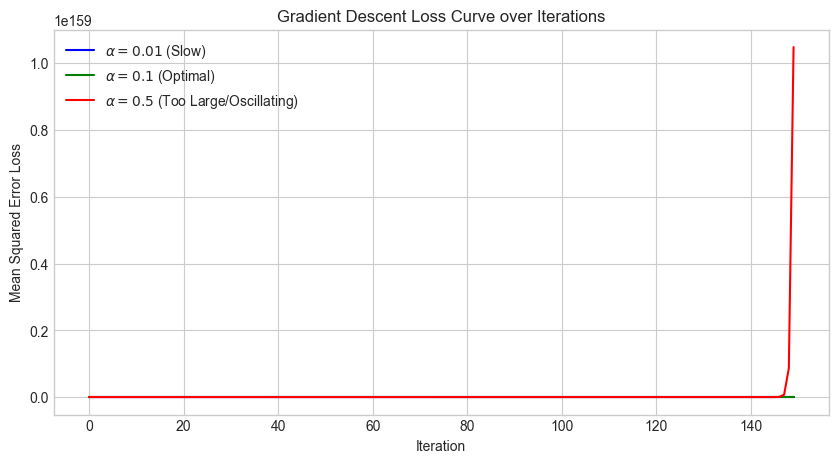

In [29]:
#funtion to perform gradient descent and learn weights
def gradient_descent(X, y, alpha = 0.1, iter = 100):
    n = len(y)
    #initialize weights to zero
    w = np.zeros(X.shape[1])
    losses = []
    
    #iterate as long as specified
    for _ in range(iter):
        #calculate predictions X * w and errors
        predictions = X.dot(w)
        errors = predictions - y
        
        #calculate MSE Loss and save in past losses
        loss = (1/n) * np.sum(errors**2)
        losses.append(loss)
        
        #calculate gradient and update weights iteratively
        gradient = (2/n) * X.T.dot(errors)
        w = w - alpha * gradient
        
    #return weights found and loss log
    return w, losses

iterations = 150

#try learning rates
w1, loss1 = gradient_descent(x_b, y, alpha = 0.01, iter = iterations)
w10, loss10 = gradient_descent(x_b, y, alpha = 0.1, iter = iterations)
w50, loss50 = gradient_descent(x_b, y, alpha = 0.5, iter = iterations)

#plot the loss curves
plt.figure(figsize = (10, 5))
plt.plot(loss1, label = r'$\alpha = 0.01$ (Slow)', color = 'blue')
plt.plot(loss10, label = r'$\alpha = 0.1$ (Optimal)', color = 'green')
plt.plot(loss50, label = r'$\alpha = 0.5$ (Too Large/Oscillating)', color = 'red')
plt.title('Gradient Descent Loss Curve over Iterations')
plt.xlabel('Iteration')
plt.ylabel('Mean Squared Error Loss')
plt.legend()
plt.show()

**Observations and Comments (4.2):**
* **Effect of Learning Rate ($\alpha$):** The learning rate determines the step size taken on the loss gradient.
* **Catastrophic Divergence ($\alpha = 0.5$):** As seen by the red curve, a learning rate of 0.5 is too aggressive. Instead of stepping toward the minimum, the algorithm overshoots it back and forth. The error increases exponentially until the loss shoots toward infinity (reaching upwards of $10^{213}$).
* **Scale Masking:** Because the diverging red curve forces the y axis to a large scale, the blue ($\alpha = 0.01$) and green ($\alpha = 0.1$) curves are visually compressed against the x axis. 
* **Convergence:** To nalyze when the optimal $\alpha = 0.1$ converges, the divergent $\alpha = 0.5$ run needs to be excluded.

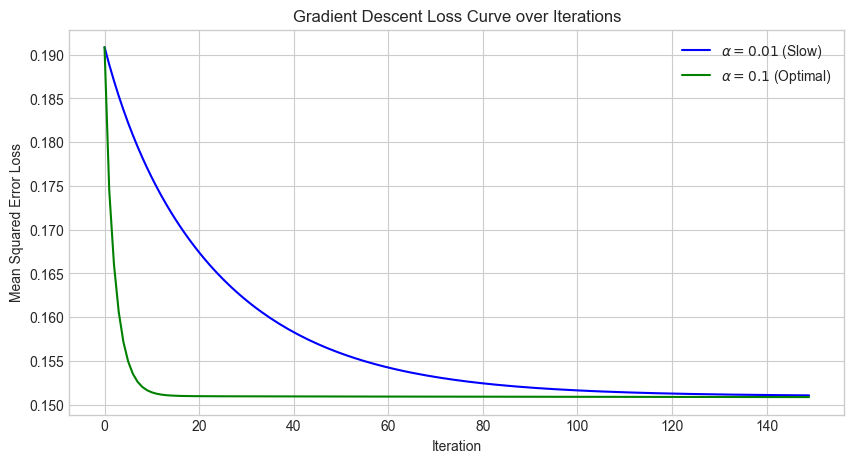

In [30]:
#plot the loss curves except oscilating red curve (a = 0.5)
plt.figure(figsize = (10, 5))
plt.plot(loss1, label = r'$\alpha = 0.01$ (Slow)', color = 'blue')
plt.plot(loss10, label = r'$\alpha = 0.1$ (Optimal)', color = 'green')
plt.title('Gradient Descent Loss Curve over Iterations')
plt.xlabel('Iteration')
plt.ylabel('Mean Squared Error Loss')
plt.legend()
plt.show()

This time, we can see that the algorithm converges around where the loss curve flattens out (the change in loss becomes negligible at ~ $< 10^{-4}$). In the optimal green curve ($\alpha = 0.1$), convergence is visually achieved around iterations 20-40, as the line becomes completely horizontal.